# Task10 — E-field & drift-velocity at the pixel and insulator surfaces

Domain `store_task10_drift_2cm_01mm-padplane` (44×44×301 @ 0.1 mm, drift-only,
node-centered pad-plane no-flux BC).
We compare the **normal** (z) vs **tangential** (x,y) components of **E** and **v_drift** at:

- **Pixel surface** — LAr node just above the copper pads (conductor → field should be ~normal).
- **Insulator surface** — the inter-pixel gap node *on the pixel plane* (z=100).
  The no-flux BC mirrors φ across this node (φ[z−1]=φ[z+1]), so the centered
  derivative gives **E_z = 0 exactly at this node** → the field is purely tangential.

Geometry (0.1 mm): FR4 insulator slab z=99 (9.9 mm), copper pads z=100 (10.0 mm),
cathode z=300 (30 mm, −1000 V). Inter-pixel gap is a cross at x,y≈[1.9,2.4] mm, center (2.2,2.2).

> **Method note.** The no-flux interface is placed *on* the pad-plane node (not the
> half-node between cells): φ is mirrored across it (φ[z−1]=φ[z+1]) so E_z vanishes
> at the very node the drift integrator samples. This supersedes the earlier
> face-centered mirror, which left the nodal E_z finite (≈12 V/mm at the gap node).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pochoir import units

STORE = "store_task10_drift_2cm_01mm-padplane"
DS    = 0.1                       # mm, grid spacing
E2VMM = units.V/units.mm         # stored E  -> V/mm   (divide)
V2MMU = units.mm/units.us        # stored v  -> mm/us  (divide)

# z-plane indices
Z_INS   = 99    # FR4 insulator node
Z_PAD   = 100   # copper pad node (also LAr in the gap columns)
Z_PIXSF = 101   # first LAr node above the pads  -> "pixel surface"
Z_INSSF = 100   # pixel-plane gap node (node-centered no-flux -> E_z = 0 here)


In [2]:
# --- load fields + geometry ---
E = np.load(f"{STORE}/velocity/efield.npz")["efield"]   / E2VMM   # (3,44,44,301) V/mm
V = np.load(f"{STORE}/velocity/drift3d.npz")["drift3d"] / V2MMU   # (3,44,44,301) mm/us
barr = np.load(f"{STORE}/boundary/drift_2cm.npz")["drift_2cm"]
ins  = np.load(f"{STORE}/initial/drift_2cm_insulator.npz")["drift_2cm_insulator"].astype(bool)

pad = barr[:, :, Z_PAD].astype(bool)   # pad footprint (x,y)
gap = ~pad                             # inter-pixel gap footprint (x,y)
nx, ny, nz = barr.shape
print("E,V shape:", E.shape, "| pad cells:", pad.sum(), "| gap cells:", gap.sum(),
      "| insulator z:", np.unique(np.where(ins.any((0,1)))[0]))


E,V shape: (3, 44, 44, 301) | pad cells: 1440 | gap cells: 496 | insulator z: [99]


In [3]:
# --- component helper: normal = z, tangential = sqrt(Ex^2+Ey^2) ---
def comps(F, z, mask):
    """Return dict of (Fx,Fy,Fz,Ft,|F|) sampled on plane z over boolean (x,y) mask."""
    Fx, Fy, Fz = (F[i, :, :, z][mask] for i in range(3))
    Ft = np.hypot(Fx, Fy)
    return dict(x=Fx, y=Fy, z=Fz, t=Ft, mag=np.hypot(Ft, Fz))

Ep = comps(E, Z_PIXSF, pad)   # E at pixel surface
Ei = comps(E, Z_INSSF, gap)   # E at insulator surface (gap only)
Vp = comps(V, Z_PIXSF, pad)   # v at pixel surface
Vi = comps(V, Z_INSSF, gap)   # v at insulator surface


## 1. Quantitative summary — normal vs tangential

In [4]:
def row(name, c):
    n, t = np.abs(c["z"]).mean(), c["t"].mean()
    frac = np.median(np.abs(c["z"]) / c["mag"])   # |normal|/|total|, 1=pure normal
    tn = f"{t/n:6.3f}" if n else "   inf"          # normal==0 => no-flux (pure tangential)
    print(f"{name:26s}  |normal|={n:9.4g}  |tangential|={t:9.4g}  "
          f"tan/norm={tn}  normal-frac(med)={frac:5.3f}")

print("E-field [V/mm]")
row("  pixel surface", Ep); row("  insulator surface", Ei)
print("\nv_drift [mm/us]")
row("  pixel surface", Vp); row("  insulator surface", Vi)
print("\nExpect: pixel -> normal-frac~1 (field ⟂ conductor);"
      " insulator -> normal ~0 (no-flux), field purely tangential.")


E-field [V/mm]
  pixel surface             |normal|=    59.14  |tangential|=    5.404  tan/norm= 0.091  normal-frac(med)=1.000
  insulator surface         |normal|=        0  |tangential|=    38.15  tan/norm=   inf  normal-frac(med)=0.000

v_drift [mm/us]
  pixel surface             |normal|=    1.721  |tangential|=   0.1407  tan/norm= 0.082  normal-frac(med)=1.000
  insulator surface         |normal|=        0  |tangential|=    1.216  tan/norm=   inf  normal-frac(med)=0.000

Expect: pixel -> normal-frac~1 (field ⟂ conductor); insulator -> normal ~0 (no-flux), field purely tangential.


## 2. Maps over the tile — normal E, tangential E, |v|
Pad outline overlaid; gap is the central cross.

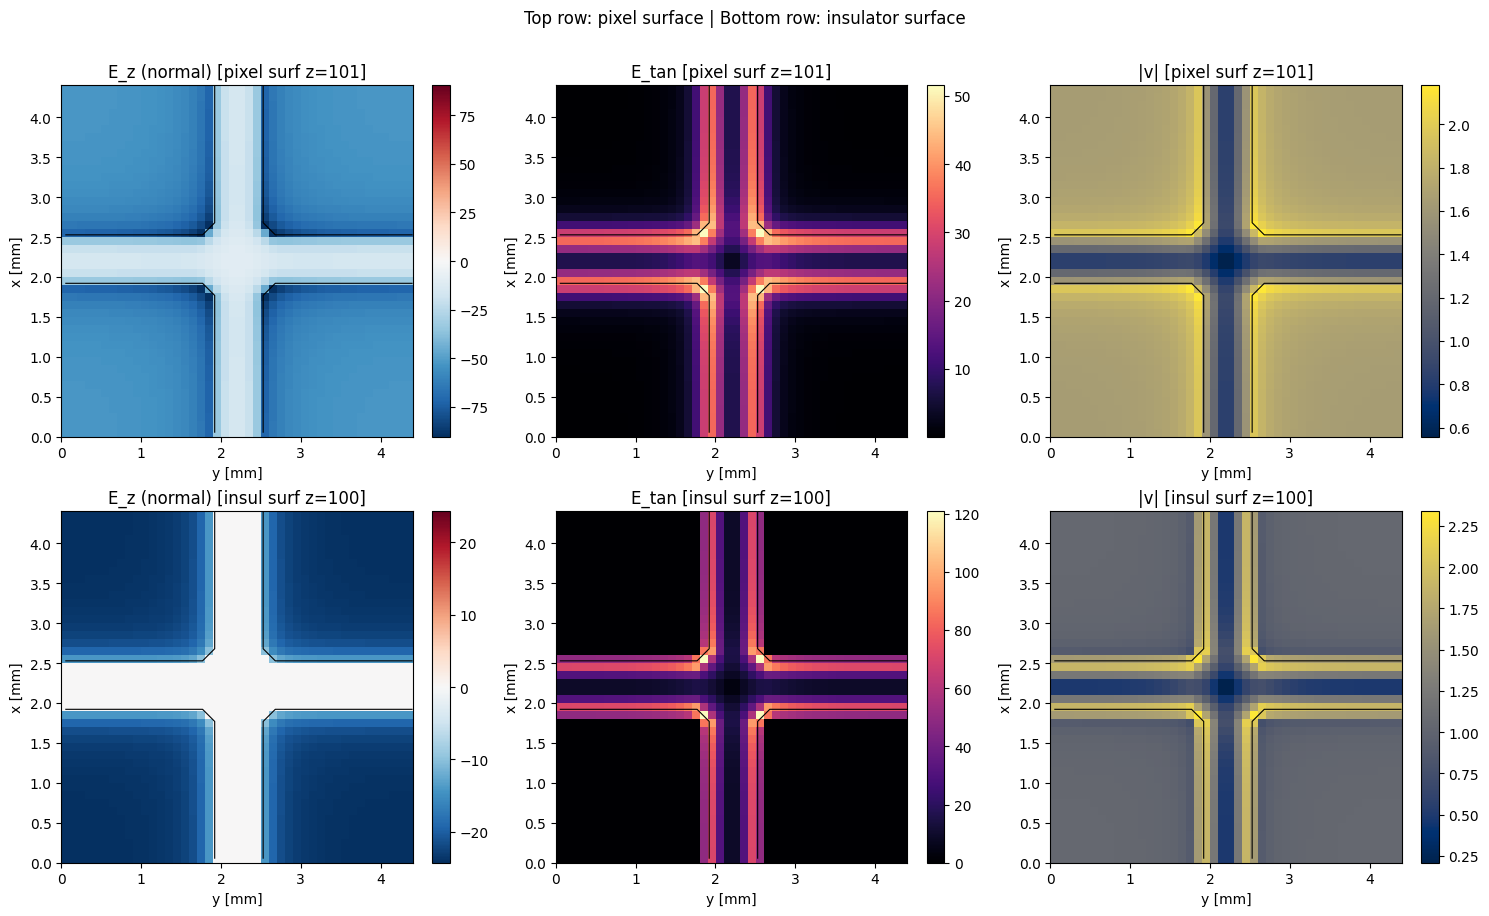

In [5]:
ext = [0, ny*DS, 0, nx*DS]     # mm (imshow: cols=y, rows=x)
def draw(ax, img, title, cmap, sym=False):
    v = np.nanmax(np.abs(img))
    kw = dict(vmin=-v, vmax=v, cmap="RdBu_r") if sym else dict(cmap=cmap)
    im = ax.imshow(img, origin="lower", extent=ext, **kw)
    ax.contour(np.linspace(DS/2, ny*DS, ny), np.linspace(DS/2, nx*DS, nx),
               pad.astype(float), levels=[0.5], colors="k", linewidths=0.8)
    ax.set_title(title); ax.set_xlabel("y [mm]"); ax.set_ylabel("x [mm]")
    plt.colorbar(im, ax=ax, fraction=0.046)

fig, axs = plt.subplots(2, 3, figsize=(15, 9))
Vmag = np.hypot(np.hypot(V[0], V[1]), V[2])
for r, (z, tag) in enumerate([(Z_PIXSF, "pixel surf z=101"), (Z_INSSF, "insul surf z=100")]):
    draw(axs[r,0], E[2,:,:,z],                 f"E_z (normal) [{tag}]", "viridis", sym=True)
    draw(axs[r,1], np.hypot(E[0,:,:,z],E[1,:,:,z]), f"E_tan [{tag}]", "magma")
    draw(axs[r,2], Vmag[:,:,z],                f"|v| [{tag}]", "cividis")
fig.suptitle("Top row: pixel surface | Bottom row: insulator surface", y=1.01)
plt.tight_layout(); plt.show()


## 3. Tangential E vectors at the insulator surface
Shows the in-plane field draining the gap toward the pad edges.

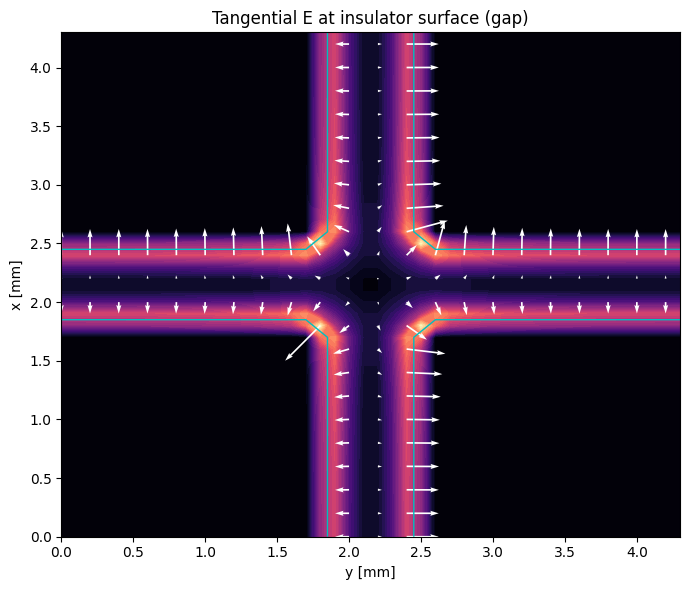

In [6]:
step = 2   # decimate arrows
xs = np.arange(nx)*DS; ys = np.arange(ny)*DS
Yg, Xg = np.meshgrid(ys, xs)
z = Z_INSSF
Ex, Ey = E[0,:,:,z].copy(), E[1,:,:,z].copy()
Ex[pad] = np.nan; Ey[pad] = np.nan            # blank pad columns

fig, ax = plt.subplots(figsize=(7,6))
ax.contourf(Yg, Xg, np.hypot(E[0,:,:,z],E[1,:,:,z]), 30, cmap="magma")
ax.quiver(Yg[::step,::step], Xg[::step,::step],
          Ey[::step,::step], Ex[::step,::step], color="w", scale_units="xy")
ax.contour(Yg, Xg, pad.astype(float), levels=[0.5], colors="c", linewidths=1)
ax.set_title("Tangential E at insulator surface (gap)"); ax.set_xlabel("y [mm]"); ax.set_ylabel("x [mm]")
plt.tight_layout(); plt.show()


## 4. Line profile across the gap
Cut along x at the gap-center row (y≈2.2 mm) through pad → gap → pad.

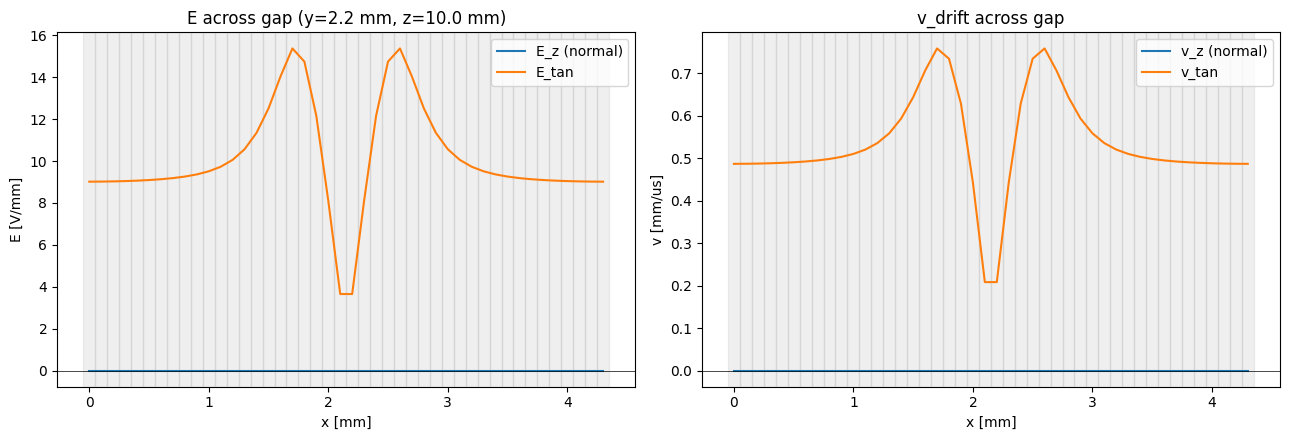

Shaded = gap (over insulator). Note E_z dips / E_tan peaks there vs the pads.


In [7]:
jy = int(round(2.2/DS))        # y index at gap center
z  = Z_INSSF
xmm = np.arange(nx)*DS
fig, axs = plt.subplots(1, 2, figsize=(13,4.5), sharex=True)
axs[0].plot(xmm, E[2,:,jy,z], label="E_z (normal)")
axs[0].plot(xmm, np.hypot(E[0,:,jy,z],E[1,:,jy,z]), label="E_tan")
axs[0].set_ylabel("E [V/mm]"); axs[0].set_title(f"E across gap (y={jy*DS:.1f} mm, z={z*DS:.1f} mm)")
axs[1].plot(xmm, V[2,:,jy,z], label="v_z (normal)")
axs[1].plot(xmm, np.hypot(V[0,:,jy,z],V[1,:,jy,z]), label="v_tan")
axs[1].set_ylabel("v [mm/us]"); axs[1].set_title("v_drift across gap")
for ax in axs:
    for xc in xmm[gap[:,jy]]: ax.axvspan(xc-DS/2, xc+DS/2, color="grey", alpha=0.12)
    ax.axhline(0, color="k", lw=.5); ax.set_xlabel("x [mm]"); ax.legend()
plt.tight_layout(); plt.show()
print("Shaded = gap (over insulator). Note E_z dips / E_tan peaks there vs the pads.")


## 5. Vertical profile — how normal E behaves approaching each surface
Gap-center column (over insulator) vs pad-center column.

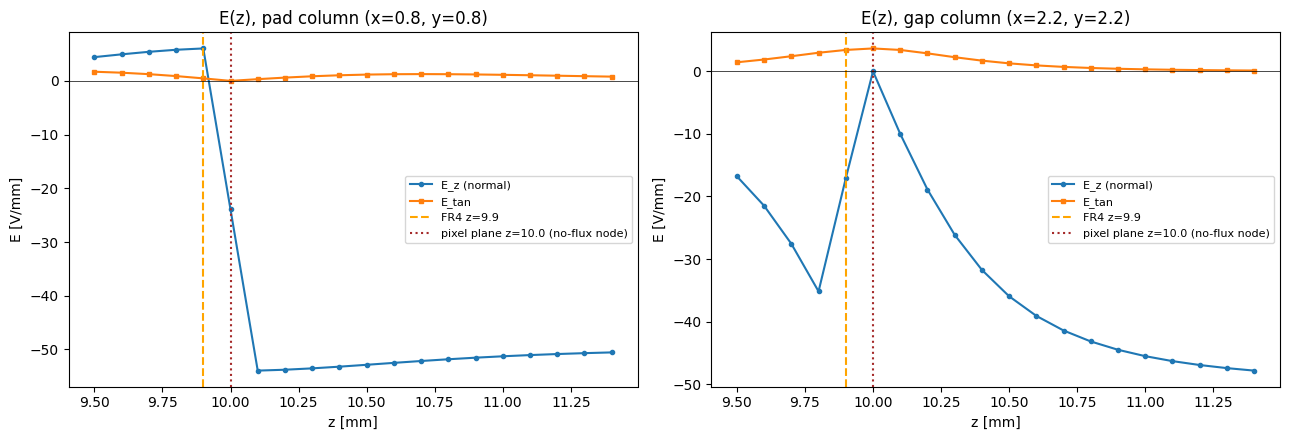

Gap column: E_z = 0 exactly at the pixel-plane node z=10.0 (node-centered no-flux); over the pad E_z stays finite/normal.


In [8]:
ix_pad, jy_pad = 8, 8          # inside a pad
ix_gap, jy_gap = int(round(2.2/DS)), int(round(2.2/DS))   # gap center
zc = np.arange(nz)*DS
zlo, zhi = 95, 115             # zoom near the pixel plane
fig, axs = plt.subplots(1, 2, figsize=(13,4.5), sharex=True)
for ax, (ix,jy,tag) in zip(axs, [(ix_pad,jy_pad,"pad column"),(ix_gap,jy_gap,"gap column")]):
    ax.plot(zc[zlo:zhi], E[2,ix,jy,zlo:zhi], "-o", ms=3, label="E_z (normal)")
    ax.plot(zc[zlo:zhi], np.hypot(E[0,ix,jy,zlo:zhi],E[1,ix,jy,zlo:zhi]), "-s", ms=3, label="E_tan")
    ax.axvline(Z_INS*DS, color="orange", ls="--", label="FR4 z=9.9")
    ax.axvline(Z_PAD*DS, color="brown",  ls=":",  label="pixel plane z=10.0 (no-flux node)")
    ax.set_title(f"E(z), {tag} (x={ix*DS:.1f}, y={jy*DS:.1f})")
    ax.set_xlabel("z [mm]"); ax.set_ylabel("E [V/mm]"); ax.axhline(0,color="k",lw=.5); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Gap column: E_z = 0 exactly at the pixel-plane node z=10.0 (node-centered no-flux); "
      "over the pad E_z stays finite/normal.")


## Summary

- **Pixel surface:** E and v are essentially **normal** (normal-frac ≈ 1) — charge lands ⟂ on the conductor.
- **Insulator surface (pixel-plane gap node):** the node-centered no-flux BC makes the
  **normal component exactly zero at the node**, leaving a purely **tangential** field/velocity
  that sweeps charge along the gap toward the pad edges instead of into it.
- The vertical profiles show E_z = 0 at the pixel-plane gap node (z=10.0 mm), but a finite
  normal field at the pads — the direct signature of the node-centered pad-plane no-flux BC
  solved by `fdm_torch` (φ[z−1]=φ[z+1]).